**Data preparation and processing**

The analysis begins by loading raw 30-second interval VTEC (Vertical Total Electron Content) data from three South African GNSS stations — HRAO, SUTH, and HERM. Invalid measurements (coded as 999.99) are removed, and the dataset is restricted to the period January 2000 to December 2023. To focus on local noon ionospheric conditions, only observations between 10:00 and 14:00 UTC are retained. Data from each station are then averaged to produce monthly and yearly time series. Missing values in the HRAO and SUTH series are filled using cubic spline interpolation. The three station datasets are merged on a common time axis.

**Solar and geomagnetic drivers**

Solar activity is represented by the F10.7 solar radio flux index, averaged monthly and filtered to the same study period. The MgII core-to-wing ratio, a UV-based solar proxy, is processed similarly. Geomagnetic activity is represented by the Dst and Ap indices, both read from raw hourly files, grouped by month, and merged with the solar data. An 81-day (3-month) rolling mean of F10.7 (F10.7a) is also computed, as required for atmospheric density modelling. Atmospheric CO₂ concentration data are loaded and merged as an additional long-term forcing variable. All driver variables are combined into a single `drivers` dataframe and filtered to the desired analysis window.

**Atmospheric neutral density**

Using the MSIS empirical atmosphere model (via `pymsis`), neutral mass density at the ionospheric shell altitude of 428.8 km is computed for each station's geographic coordinates on a monthly basis, using the corresponding F10.7 and Ap values as inputs.

**Statistical modelling**

The solar and geomagnetic driver variables are standardised using z-score scaling to allow direct comparison of regression coefficients. Ordinary Least Squares (OLS) regression is then applied separately for each station, with the standardised drivers as predictors and monthly mean VTEC as the dependent variable. Variance Inflation Factors (VIF) are computed to assess multicollinearity. Model diagnostics include observed versus predicted scatter plots, residual plots, Q–Q plots, and full time series comparisons of observed and modelled VTEC across all three stations.

# Import GNSS station data: HRAO, SUTH, HERM

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## HRAO

In [2]:
hrao = pd.read_csv("/home/user/Documents/MScResearch/2024/Software/ionolabtecv1.41/30s_interval_data(hrao).txt")

# Replace 999.99 with NaN in the entire DataFrame
hrao.replace(999.99, np.nan, inplace=True)
hrao = hrao.dropna(how="all")

# Rename a specific column
hrao = hrao.rename(columns={'Time (UTC)': 'YearMonth'})
begin = '2000-01-01'
end = '2023-12-31'

hrao = hrao[(hrao['YearMonth'] >= begin) & (hrao['YearMonth'] <= end)]
hrao['YearMonth'] = pd.to_datetime(hrao['YearMonth'])

# Filter rows using the precomputed 'time' column. THese are noon times
hrao = hrao[(hrao['YearMonth'].dt.time >= pd.to_datetime('10:00:00').time()) &
                 (hrao['YearMonth'].dt.time <= pd.to_datetime('14:00:00').time())]

hrao['YearMonth'] = pd.to_datetime(hrao['YearMonth'])
hrao

,YearMonth,VTEC (TECU)
1200,2005-12-30 10:00:00,28.15
1201,2005-12-30 10:00:30,28.14
1202,2005-12-30 10:01:00,28.14
1203,2005-12-30 10:01:30,28.14
1204,2005-12-30 10:02:00,28.14
...,...,...
32659520,2000-05-11 13:30:00,48.32
32659521,2000-05-11 13:37:30,48.19
32659522,2000-05-11 13:45:00,48.12
32659523,2000-05-11 13:52:30,47.99


In [3]:
# Group Monthly
hrao_monthly = hrao.groupby(hrao['YearMonth'].dt.to_period('M'))['VTEC (TECU)'].mean().reset_index()
hrao_monthly

# Group Yearly
hrao_yearly = hrao.groupby(hrao['YearMonth'].dt.to_period('Y'))['VTEC (TECU)'].mean().reset_index()
hrao_yearly

,YearMonth,VTEC (TECU)
0,2000,54.137085
1,2001,55.674417
2,2002,58.211557
3,2003,36.577396
4,2004,26.043430
5,2005,22.375398
6,2006,16.796759
7,2007,12.221102
8,2008,12.519116
9,2009,12.290912


## SUTH

In [4]:
import pandas as pd
import numpy as np

suth = pd.read_csv("/home/user/Documents/MScResearch/2024/Software/ionolabtecv1.41/30s_interval_data(suth).txt")

# Replace 999.99 with NaN in the entire DataFrame
suth.replace(999.99, np.nan, inplace=True)
suth = suth.dropna(how="all")

# Rename a specific column
suth = suth.rename(columns={'Time (UTC)': 'YearMonth'})
begin = '2000-01-01'
end = '2023-12-31'

suth = suth[(suth['YearMonth'] >= begin) & (suth['YearMonth'] <= end)]
suth['YearMonth'] = pd.to_datetime(suth['YearMonth'])

# Filter rows using the precomputed 'time' column. THese are noon times
suth = suth[(suth['YearMonth'].dt.time >= pd.to_datetime('10:00:00').time()) &
                 (suth['YearMonth'].dt.time <= pd.to_datetime('14:00:00').time())]

suth['YearMonth'] = pd.to_datetime(suth['YearMonth'])
suth

,YearMonth,VTEC (TECU)
1200,2020-07-06 10:00:00,4.92
1201,2020-07-06 10:00:30,4.92
1202,2020-07-06 10:01:00,4.92
1203,2020-07-06 10:01:30,4.92
1204,2020-07-06 10:02:00,4.92
...,...,...
21019916,2007-05-17 13:58:00,8.12
21019917,2007-05-17 13:58:30,8.11
21019918,2007-05-17 13:59:00,8.09
21019919,2007-05-17 13:59:30,8.09


In [5]:
# Group Monthly
suth_monthly = suth.groupby(suth['YearMonth'].dt.to_period('M'))['VTEC (TECU)'].mean().reset_index()
suth_monthly

# Group Yearly
suth_yearly = suth.groupby(suth['YearMonth'].dt.to_period('Y'))['VTEC (TECU)'].mean().reset_index()
suth_yearly

,YearMonth,VTEC (TECU)
0,2000,58.466870
1,2001,56.499546
2,2002,56.751040
3,2003,34.392628
4,2004,25.026258
5,2005,21.852211
6,2006,15.476134
7,2007,13.020313
8,2008,11.587786
9,2009,12.948227


# HERM

In [6]:
import pandas as pd
import numpy as np

herm = pd.read_csv("/home/user/Documents/MScResearch/2024/Software/ionolabtecv1.41/30s_interval_data(herm).txt")

# Replace 999.99 with NaN in the entire DataFrame
herm.replace(999.99, np.nan, inplace=True)
herm = herm.dropna(how="all")

# Rename a specific column
herm = herm.rename(columns={'Time (UTC)': 'YearMonth'})
begin = '2000-01-01'
end = '2023-12-31'

herm = herm[(herm['YearMonth'] >= begin) & (herm['YearMonth'] <= end)]
herm['YearMonth'] = pd.to_datetime(herm['YearMonth'])

# Filter rows using the precomputed 'time' column. THese are noon times
herm = herm[(herm['YearMonth'].dt.time >= pd.to_datetime('10:00:00').time()) &
                 (herm['YearMonth'].dt.time <= pd.to_datetime('14:00:00').time())]

herm['YearMonth'] = pd.to_datetime(herm['YearMonth'])
herm

,Unnamed: 0,YearMonth,VTEC (TECU)
1177,1177,2009-06-25 10:00:00,5.33
1178,1178,2009-06-25 10:00:30,5.33
1179,1179,2009-06-25 10:01:00,5.33
1180,1180,2009-06-25 10:01:30,5.33
1181,1181,2009-06-25 10:02:00,5.33
...,...,...,...
9924848,9924848,2016-03-15 13:58:00,19.56
9924849,9924849,2016-03-15 13:58:30,19.55
9924850,9924850,2016-03-15 13:59:00,19.54
9924851,9924851,2016-03-15 13:59:30,19.54


In [7]:
#Group Monthly
herm_monthly = herm.groupby(herm['YearMonth'].dt.to_period('M'))['VTEC (TECU)'].mean().reset_index()
herm_monthly

# Group Yearly
herm_yearly = herm.groupby(herm['YearMonth'].dt.to_period('Y'))['VTEC (TECU)'].mean().reset_index()
herm_yearly

,YearMonth,VTEC (TECU)
0,2000,52.562771
1,2001,42.897128
2,2002,53.277875
3,2003,34.837455
4,2004,23.940652
5,2005,18.690397
6,2006,12.551679
7,2007,14.987168
8,2008,11.250615
9,2009,11.586635


## Merge GNSS Stations

In [8]:
#Instead of getting 'Value_x' and 'Value_y'
stations = hrao.merge(suth, on='YearMonth')
print(stations)
stations = stations.merge(herm, on='YearMonth')
stations

                  YearMonth  VTEC (TECU)_x  VTEC (TECU)_y
0       2005-12-30 10:00:00          28.15          24.06
1       2005-12-30 10:00:30          28.14          24.06
2       2005-12-30 10:01:00          28.14          24.05
3       2005-12-30 10:01:30          28.14          24.04
4       2005-12-30 10:02:00          28.14          24.03
...                     ...            ...            ...
2317170 2000-05-11 13:30:00          48.32          57.10
2317171 2000-05-11 13:37:30          48.19          57.07
2317172 2000-05-11 13:45:00          48.12          57.10
2317173 2000-05-11 13:52:30          47.99          57.19
2317174 2000-05-11 14:00:00          47.83          57.16

[2317175 rows x 3 columns]


,YearMonth,VTEC (TECU)_x,VTEC (TECU)_y,Unnamed: 0,VTEC (TECU)
0,2008-11-10 10:00:00,17.76,14.70,7489594,14.18
1,2008-11-10 10:00:30,17.77,14.71,7489595,14.19
2,2008-11-10 10:01:00,17.78,14.71,7489596,14.20
3,2008-11-10 10:01:30,17.78,14.72,7489597,14.21
4,2008-11-10 10:02:00,17.80,14.72,7489598,14.22
...,...,...,...,...,...
951159,2000-05-11 13:30:00,48.32,57.10,9367154,54.16
951160,2000-05-11 13:37:30,48.19,57.07,9367169,54.16
951161,2000-05-11 13:45:00,48.12,57.10,9367184,53.92
951162,2000-05-11 13:52:30,47.99,57.19,9367199,53.83


In [9]:
#Rename somee columns
stations = stations.rename(columns={
    'VTEC (TECU)_x': 'hrao-VTEC',
    'VTEC (TECU)_y': 'suth-VTEC',
    'VTEC (TECU)': 'herm-VTEC'
})
stations

,YearMonth,hrao-VTEC,suth-VTEC,Unnamed: 0,herm-VTEC
0,2008-11-10 10:00:00,17.76,14.70,7489594,14.18
1,2008-11-10 10:00:30,17.77,14.71,7489595,14.19
2,2008-11-10 10:01:00,17.78,14.71,7489596,14.20
3,2008-11-10 10:01:30,17.78,14.72,7489597,14.21
4,2008-11-10 10:02:00,17.80,14.72,7489598,14.22
...,...,...,...,...,...
951159,2000-05-11 13:30:00,48.32,57.10,9367154,54.16
951160,2000-05-11 13:37:30,48.19,57.07,9367169,54.16
951161,2000-05-11 13:45:00,48.12,57.10,9367184,53.92
951162,2000-05-11 13:52:30,47.99,57.19,9367199,53.83


In [10]:
#Check for missing data
print(stations.isnull().sum())

YearMonth        0
hrao-VTEC     4805
suth-VTEC     4745
Unnamed: 0       0
herm-VTEC        0
dtype: int64


### Lets c-spline interpolate missing values
#### This is a 3rd degree order polynomial interploation

In [11]:
stations['hrao-VTEC'] = stations['hrao-VTEC'].interpolate(method='spline', order=3)
stations['suth-VTEC'] = stations['suth-VTEC'].interpolate(method='spline', order=3)

In [12]:
stations = stations.drop('Unnamed: 0', axis=1)
print(stations.isnull().sum())

YearMonth    0
hrao-VTEC    0
suth-VTEC    0
herm-VTEC    0
dtype: int64


In [13]:
# GroupMonthly
stations_monthly = stations.groupby(stations['YearMonth'].dt.to_period('M')).mean().reset_index()

# Group Yearly
stations_yearly = stations.groupby(stations['YearMonth'].dt.to_period('Y')).mean().reset_index()

# Imprt the predictors

## Import monthly averaged F10.7 data

In [14]:
import pandas as pd

F10_data2 = pd.read_csv("/home/user/Documents/MScResearch/2024/Software/ionolabtecv1.41/F10.7 dataII.txt", header=None, names=['fractional year', 'month', 'day', 'Solar Flux Units (SFU)', 'index'], delimiter=r'\s+')

#Make sure that the fractional year column is numric, else it will give errors
F10_data2['fractional year'] = pd.to_numeric(F10_data2['fractional year'], errors='coerce')

# Combine columns to create a proper date
# Extract the year as an integer from 'fractional year'
F10_data2['year'] = F10_data2['fractional year'].astype(int)

# Create a datetime column
F10_data2['YearMonth'] = pd.to_datetime(F10_data2[['year', 'month', 'day']])

F10_data2.insert(0, 'YearMonth', F10_data2.pop('YearMonth'))

F10_data2['YearMonth'] = pd.to_datetime(F10_data2['YearMonth'], errors='coerce')

F10_data2['index'] = pd.to_numeric(F10_data2['index'], errors='coerce')

F10_data2 = F10_data2[(F10_data2['YearMonth'] >= '2000-01') & (F10_data2['YearMonth'] <= '2023-12')]

F10_data2['YearMonth'] = pd.to_datetime(F10_data2['YearMonth'], errors='coerce')
F10_data2_grouped = F10_data2.groupby(F10_data2['YearMonth'].dt.to_period('M'))['Solar Flux Units (SFU)'].mean().reset_index()

# Convert 'YearMonth' back to datetime for plotting
F10_data2_grouped['YearMonth'] = F10_data2_grouped['YearMonth'].dt.to_timestamp()
#print(F10_data2_grouped)
f107 = F10_data2_grouped
f107
f107['Solar Flux Units (SFU)'] = pd.to_numeric(f107['Solar Flux Units (SFU)'], errors='coerce')

## Import monthly averaged MgII data

In [15]:
import pandas as pd

#F30_data = pd.read_csv("MgII data.txt", header=None, names=['fractional year', 'month', 'day', 'index', 'uncertainty(1s)', 'source id', 'nan'], delimiter=r'\s+', on_bad_lines="skip")
cols = ["fractional_year", "month", "day", "index", "uncertainty", "source_id"]

F30_data = pd.read_csv(
    "/home/user/Documents/MScResearch/2024/Software/ionolabtecv1.41/MgII data.txt",
    delim_whitespace=True,   # split on whitespace
    comment=";",             # ignore header/comment lines starting with ";"
    names=cols,              # assign correct column names
    usecols=range(len(cols)) # only keep the first 6 columns
)

# Drop the first 14 rows, the header
#F30_data = F30_data.iloc[0:].reset_index(drop=True)

# Drop rows where fractional_year is missing
F30_data = F30_data.dropna(subset=['fractional_year'])
#Make sure that the fractional year column is numric, else it will give errors
F30_data['fractional_year'] = pd.to_numeric(F30_data['fractional_year'], errors='coerce')

# Combine columns to create a proper date
# Extract the year as an integer from 'fractional year'
F30_data['year'] = F30_data['fractional_year'].astype(int)

# Create a datetime column
F30_data['YearMonth'] = pd.to_datetime(F30_data[['year', 'month', 'day']])

F30_data.insert(0, 'YearMonth', F30_data.pop('YearMonth'))

F30_data['fractional_year'] = pd.to_numeric(F30_data['fractional_year'], errors='coerce')
F30_data['month'] = pd.to_numeric(F30_data['month'], errors='coerce')
F30_data['day'] = pd.to_numeric(F30_data['day'], errors='coerce')

F30_data['YearMonth'] = pd.to_datetime(F30_data['YearMonth'], errors='coerce')

F30_data['index'] = pd.to_numeric(F30_data['index'], errors='coerce')

F30_data = F30_data[(F30_data['YearMonth'] >= '2000-01') & (F30_data['YearMonth'] <= '2023-12')]

F30_data['YearMonth'] = pd.to_datetime(F30_data['YearMonth'], errors='coerce')
F30_data = F30_data.groupby(F30_data['YearMonth'].dt.to_period('M'))['index'].mean().reset_index()

# Convert 'YearMonth' back to datetime for plotting
F30_data['YearMonth'] = F30_data['YearMonth'].dt.to_timestamp()
# drop useless columns
#F30_data = F30_data.drop(columns=['fractional_year', 'month', 'day', 'uncertainty', 'source_id', 'year'])
MgII = F30_data
MgII

,YearMonth,index
0,2000-01-01,0.162888
1,2000-02-01,0.163873
2,2000-03-01,0.166160
3,2000-04-01,0.166270
4,2000-05-01,0.164477
...,...,...
283,2023-08-01,0.165600
284,2023-09-01,0.164897
285,2023-10-01,0.164727
286,2023-11-01,0.164394


## Import Ap data

In [16]:
ap = pd.read_csv("ap_hourly_all_years.csv")
print(ap)

# group by month
ap['datetime'] = pd.to_datetime(ap['datetime'], errors='coerce')
ap = ap.groupby(ap['datetime'].dt.to_period('M'))['ap'].mean().reset_index()
#remane 'datetime' to 'YearMonth' for simplicity
ap = ap.rename(columns={'datetime': 'YearMonth'})

# Convert 'YearMonth' back to datetime for plotting
ap['YearMonth'] = ap['YearMonth'].dt.to_timestamp() 
# filter the time period
ap = ap[(ap['YearMonth'] >= '2000-01') & (ap['YearMonth'] <= '2023-12')]
print(ap)

                  datetime     ap
0      2000-01-08 00:00:00      6
1      2000-01-08 03:00:00      9
2      2000-01-08 06:00:00      3
3      2000-01-08 09:00:00      0
4      2000-01-08 12:00:00     50
...                    ...    ...
83263  2099-12-29 09:00:00     12
83264  2099-12-29 12:00:00     80
83265  2099-12-29 15:00:00     42
83266  2099-12-29 18:00:00  75139
83267  2099-12-29 21:00:00      0

[83268 rows x 2 columns]
     YearMonth             ap
0   2000-01-01    1573.208333
1   2000-02-01       8.333333
2   2000-03-01  967131.666667
3   2000-04-01  975394.187500
4   2000-05-01  633332.625000
..         ...            ...
211 2017-12-01      12.054688
212 2018-01-01      11.256579
213 2018-02-01       5.850000
214 2018-03-01      14.951389
215 2018-04-01      12.931250

[216 rows x 2 columns]


## Import DST data

In [17]:
dst = pd.read_csv("dst_hourly_all_years.csv")
# group by month
dst['datetime'] = pd.to_datetime(dst['datetime'], errors='coerce')
dst = dst.groupby(dst['datetime'].dt.to_period('M'))['dst'].mean().reset_index()
#remane 'datetime' to 'YearMonth' for simplicity
dst = dst.rename(columns={'datetime': 'YearMonth'})

# Convert 'YearMonth' back to datetime for plotting
dst['YearMonth'] = dst['YearMonth'].dt.to_timestamp()
# filter the time period
dst = dst[(dst['YearMonth'] >= '2000-01') & (dst['YearMonth'] <= '2023-12')]
print(dst)

     YearMonth        dst
516 2000-01-01 -18.616379
517 2000-02-01 -18.712798
518 2000-03-01  -6.358790
519 2000-04-01 -26.670118
520 2000-05-01 -15.392603
..         ...        ...
656 2011-09-01 -10.325409
657 2011-10-01  -7.139368
658 2011-11-01  -9.470060
659 2011-12-01  -4.031157
660 2012-01-01  -5.882698

[145 rows x 2 columns]


# Merge solar and geomagnetic drivers

In [18]:
drivers = f107.merge(MgII, on='YearMonth')
drivers = drivers.merge(dst, on='YearMonth')
drivers = drivers.merge(ap, on='YearMonth')
drivers

,YearMonth,Solar Flux Units (SFU),index,dst,ap
0,2000-01-01,153.432258,0.162888,-18.616379,1573.208333
1,2000-02-01,168.589310,0.163873,-18.712798,8.333333
2,2000-03-01,206.673548,0.166160,-6.358790,967131.666667
3,2000-04-01,185.490000,0.166270,-26.670118,975394.187500
4,2000-05-01,188.385484,0.164477,-15.392603,633332.625000
...,...,...,...,...,...
136,2011-09-01,135.941667,0.158742,-10.325409,4080.892857
137,2011-10-01,136.380645,0.160007,-7.139368,208543.157895
138,2011-11-01,149.880000,0.161720,-9.470060,120964.886905
139,2011-12-01,136.896774,0.161219,-4.031157,59488.551136


## Filter the time period of your solar drivers to your desired

In [19]:
drivers = drivers.rename(columns={'Solar Flux Units (SFU)': 'f107'})
drivers = drivers[(drivers['YearMonth'] >= "2000-01-01") & (drivers['YearMonth'] <= "2016-12-31")]

## Import CO2 monthly data

In [20]:
import pandas as pd
CO2_data = pd.read_csv("/home/user/Documents/MScResearch/2024/Software/ionolabtecv1.41/CO2_data.txt", header=None, delim_whitespace=True, names= ['Year', 'Month', 'decimal date', 'monthly average', 'de-seasonalized', 'Days', 'st. dev of days', 'unc. of mon mean'])

CO2_data = CO2_data.iloc[14:].reset_index(drop=True)

# Merge year, month into a new column 'YearMonth'
CO2_data['YearMonth'] = CO2_data['Year'].astype(str) + '-' + CO2_data['Month'].astype(str).str.zfill(2)
CO2_data['YearMonth'] = pd.to_datetime(CO2_data['YearMonth'], errors='coerce')

CO2_data = CO2_data[(CO2_data['YearMonth'] >= '2000-01') & (CO2_data['YearMonth'] <= '2023-12')]
print(CO2_data)

     Year  Month  decimal date  monthly average  de-seasonalized  Days  \
488  2000      1     2000.0417           369.45           369.24    26   
489  2000      2     2000.1250           369.71           368.99    19   
490  2000      3     2000.2083           370.75           369.24    30   
491  2000      4     2000.2917           371.98           369.44    27   
492  2000      5     2000.3750           371.74           368.87    28   
..    ...    ...           ...              ...              ...   ...   
771  2023      8     2023.6250           419.68           421.55    21   
772  2023      9     2023.7083           418.50           421.92    18   
773  2023     10     2023.7917           418.82           422.12    27   
774  2023     11     2023.8750           420.46           422.49    21   
775  2023     12     2023.9583           421.86           422.57    20   

     st. dev of days  unc. of mon mean  YearMonth  
488             0.48              0.18 2000-01-01  
489    

In [21]:
CO2_data = CO2_data.drop(columns=['Year','Month','decimal date','de-seasonalized','Days','st. dev of days','unc. of mon mean'])
CO2_data = CO2_data.set_index('YearMonth')
CO2_data = CO2_data.reset_index('YearMonth')
CO2_data['YearMonth'] = pd.to_datetime(CO2_data['YearMonth'])
CO2_data = CO2_data.rename(columns={'monthly average': 'CO2_Level'})
CO2_data

,YearMonth,CO2_Level
0,2000-01-01,369.45
1,2000-02-01,369.71
2,2000-03-01,370.75
3,2000-04-01,371.98
4,2000-05-01,371.74
...,...,...
283,2023-08-01,419.68
284,2023-09-01,418.50
285,2023-10-01,418.82
286,2023-11-01,420.46


In [22]:
# merge CO2 with the drivers
drivers = drivers.merge(CO2_data, on='YearMonth')
drivers

,YearMonth,f107,index,dst,ap,CO2_Level
0,2000-01-01,153.432258,0.162888,-18.616379,1573.208333,369.45
1,2000-02-01,168.589310,0.163873,-18.712798,8.333333,369.71
2,2000-03-01,206.673548,0.166160,-6.358790,967131.666667,370.75
3,2000-04-01,185.490000,0.166270,-26.670118,975394.187500,371.98
4,2000-05-01,188.385484,0.164477,-15.392603,633332.625000,371.74
...,...,...,...,...,...,...
136,2011-09-01,135.941667,0.158742,-10.325409,4080.892857,389.28
137,2011-10-01,136.380645,0.160007,-7.139368,208543.157895,389.19
138,2011-11-01,149.880000,0.161720,-9.470060,120964.886905,390.48
139,2011-12-01,136.896774,0.161219,-4.031157,59488.551136,392.06


## Visualise some stuff

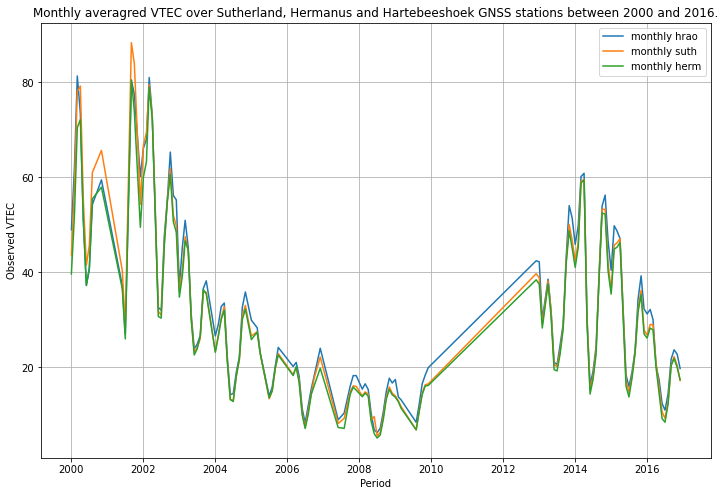

In [23]:
plt.figure(figsize=(12, 8))

plt.plot(stations_monthly['YearMonth'].dt.to_timestamp(), stations_monthly['hrao-VTEC'], label='monthly hrao')
plt.plot(stations_monthly['YearMonth'].dt.to_timestamp(), stations_monthly['suth-VTEC'], label='monthly suth')
plt.plot(stations_monthly['YearMonth'].dt.to_timestamp(), stations_monthly['herm-VTEC'], label='monthly herm')
plt.legend()
plt.title("Monthly averagred VTEC over Sutherland, Hermanus and Hartebeeshoek GNSS stations between 2000 and 2016.")
plt.xlabel("Period")
plt.ylabel("Observed VTEC")
plt.grid()
plt.show()

From the above figure, it seems as if between 2010 and 2013 there is missing data even though I interpolated.
Below I plot the that period to comfirm whether there is data or not.

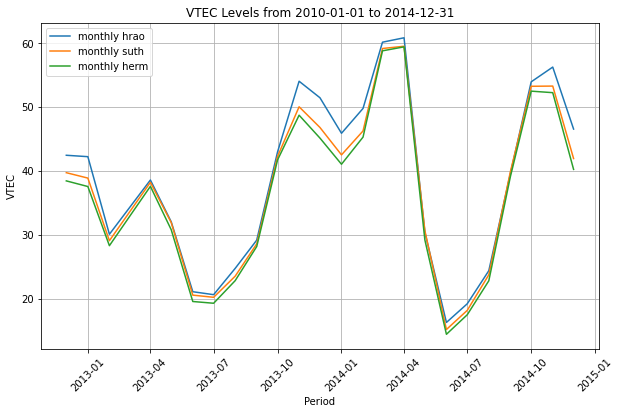

In [24]:
# This part I used GEMINI to produce
# 1. Define your window
start_date = '2010-01-01'
end_date = '2014-12-31'

# 2. Create the subset (assuming YearMonth is a column)
# If YearMonth is a Period object, we convert to timestamp to compare easily
mask = (stations_monthly['YearMonth'].dt.to_timestamp() >= start_date) & \
       (stations_monthly['YearMonth'].dt.to_timestamp() <= end_date)

plot_data = stations_monthly.loc[mask]

# 3. Plot using the subset
plt.figure(figsize=(10, 6))

plt.plot(plot_data['YearMonth'].dt.to_timestamp(), plot_data['hrao-VTEC'], label='monthly hrao')
plt.plot(plot_data['YearMonth'].dt.to_timestamp(), plot_data['suth-VTEC'], label='monthly suth')
plt.plot(plot_data['YearMonth'].dt.to_timestamp(), plot_data['herm-VTEC'], label='monthly herm')

# 4. Final touches
plt.legend()
plt.title(f"VTEC Levels from {start_date} to {end_date}")
plt.xlabel("Period")
plt.ylabel("VTEC")
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [25]:
stations.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 951164 entries, 0 to 951163
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   YearMonth  951164 non-null  datetime64[ns]
 1   hrao-VTEC  951164 non-null  float64       
 2   suth-VTEC  951164 non-null  float64       
 3   herm-VTEC  951164 non-null  float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 36.3 MB


Therefore there aren't any missing data or NAN elements

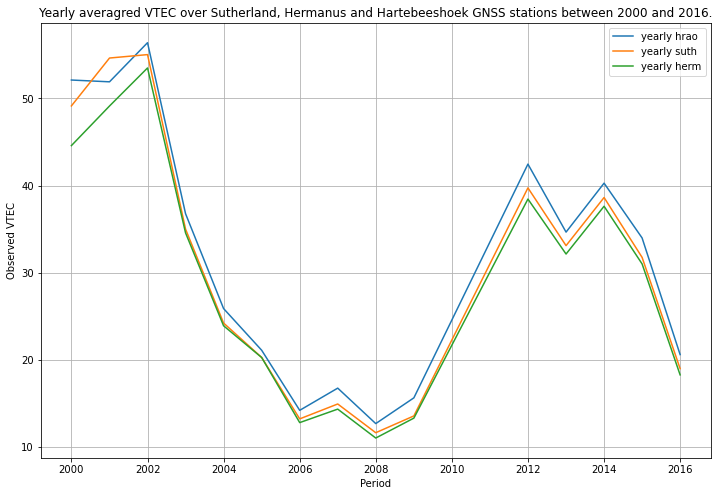

In [26]:
plt.figure(figsize=(12, 8))

plt.plot(stations_yearly['YearMonth'].dt.to_timestamp(), stations_yearly['hrao-VTEC'], label='yearly hrao')
plt.plot(stations_yearly['YearMonth'].dt.to_timestamp(), stations_yearly['suth-VTEC'], label='yearly suth')
plt.plot(stations_yearly['YearMonth'].dt.to_timestamp(), stations_yearly['herm-VTEC'], label='yearly herm')
plt.legend()
plt.title("Yearly averagred VTEC over Sutherland, Hermanus and Hartebeeshoek GNSS stations between 2000 and 2016.")
plt.xlabel("Period")
plt.ylabel("Observed VTEC")
plt.grid()
plt.show()

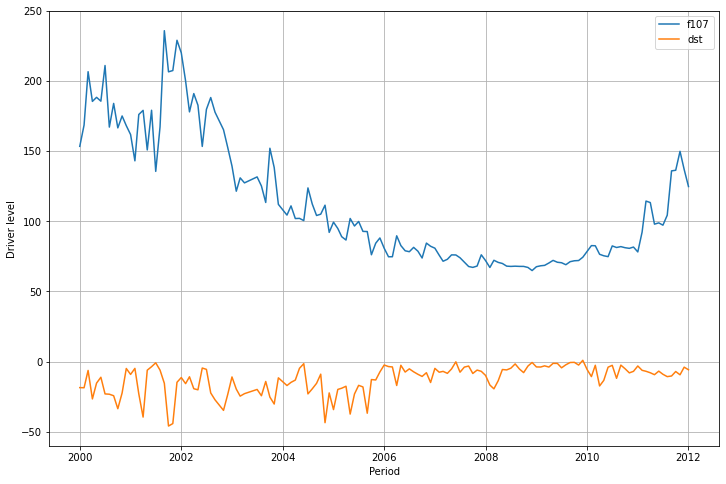

In [27]:
plt.figure(figsize=(12, 8))

plt.plot(drivers['YearMonth'], drivers['f107'], label='f107')
plt.plot(drivers['YearMonth'], drivers['dst'], label='dst')
plt.xlabel("Period")
plt.ylabel("Driver level")
plt.legend()
plt.grid()
plt.show()

In [28]:
drivers

,YearMonth,f107,index,dst,ap,CO2_Level
0,2000-01-01,153.432258,0.162888,-18.616379,1573.208333,369.45
1,2000-02-01,168.589310,0.163873,-18.712798,8.333333,369.71
2,2000-03-01,206.673548,0.166160,-6.358790,967131.666667,370.75
3,2000-04-01,185.490000,0.166270,-26.670118,975394.187500,371.98
4,2000-05-01,188.385484,0.164477,-15.392603,633332.625000,371.74
...,...,...,...,...,...,...
136,2011-09-01,135.941667,0.158742,-10.325409,4080.892857,389.28
137,2011-10-01,136.380645,0.160007,-7.139368,208543.157895,389.19
138,2011-11-01,149.880000,0.161720,-9.470060,120964.886905,390.48
139,2011-12-01,136.896774,0.161219,-4.031157,59488.551136,392.06


In [29]:
stations_monthly

,YearMonth,hrao-VTEC,suth-VTEC,herm-VTEC
0,2000-01,48.984570,43.678421,39.683801
1,2000-02,62.031318,58.217056,52.033924
2,2000-03,81.367264,78.160147,70.509034
3,2000-04,73.485655,79.246056,72.160000
4,2000-05,51.021451,55.409806,51.092551
...,...,...,...,...
129,2016-08,14.466417,12.773159,12.323604
130,2016-09,21.757465,20.502670,20.395894
131,2016-10,23.705247,22.271101,21.872049
132,2016-11,22.798002,20.444004,19.985979


In [30]:
stations_yearly

,YearMonth,hrao-VTEC,suth-VTEC,herm-VTEC
0,2000,52.122735,49.145862,44.584323
1,2001,51.916779,54.650881,49.137128
2,2002,56.413963,55.044067,53.510119
3,2003,36.759593,34.990830,34.556030
4,2004,25.859309,24.195838,23.881899
5,2005,21.064091,20.235651,20.231062
6,2006,14.162678,13.179985,12.751614
7,2007,16.714279,14.893003,14.301266
8,2008,12.639170,11.589918,10.979079
9,2009,15.597406,13.520216,13.267911


## Merge stations and drivers

In [31]:
stations_monthly['YearMonth'] = stations_monthly['YearMonth'].dt.to_timestamp()
#stations_monthly = stations_monthly.reset_index('YearMonth')
stations_monthly['YearMonth'] = pd.to_datetime(stations_monthly['YearMonth'])
monthly_data = drivers.merge(stations_monthly, on='YearMonth')
print(monthly_data.isnull().sum())
print(monthly_data)

YearMonth    0
f107         0
index        0
dst          0
ap           0
CO2_Level    0
hrao-VTEC    0
suth-VTEC    0
herm-VTEC    0
dtype: int64
    YearMonth        f107     index        dst             ap  CO2_Level  \
0  2000-01-01  153.432258  0.162888 -18.616379    1573.208333     369.45   
1  2000-02-01  168.589310  0.163873 -18.712798       8.333333     369.71   
2  2000-03-01  206.673548  0.166160  -6.358790  967131.666667     370.75   
3  2000-04-01  185.490000  0.166270 -26.670118  975394.187500     371.98   
4  2000-05-01  188.385484  0.164477 -15.392603  633332.625000     371.74   
..        ...         ...       ...        ...            ...        ...   
78 2009-08-01   69.025806  0.150467  -2.333333      10.515000     386.29   
79 2009-09-01   71.193333  0.150827  -0.706065      10.476852     384.95   
80 2009-10-01   71.835484  0.151199  -0.593842       8.883621     384.64   
81 2009-11-01   72.016667  0.151580  -2.535660       7.718750     386.23   
82 2009-12-01   

In [32]:
stations_yearly['YearMonth'] = stations_yearly['YearMonth'].dt.to_timestamp()
#stations_monthly = stations_monthly.reset_index('YearMonth')
stations_yearly['YearMonth'] = pd.to_datetime(stations_yearly['YearMonth'])
yearly_data = drivers.merge(stations_yearly, on='YearMonth')
print(yearly_data.isnull().sum())
print(yearly_data)

YearMonth    0
f107         0
index        0
dst          0
ap           0
CO2_Level    0
hrao-VTEC    0
suth-VTEC    0
herm-VTEC    0
dtype: int64
   YearMonth        f107     index        dst             ap  CO2_Level  \
0 2000-01-01  153.432258  0.162888 -18.616379    1573.208333     369.45   
1 2001-01-01  161.831935  0.163849  -9.208455  586821.680556     370.76   
2 2002-01-01  220.109355  0.171310 -11.430216  265036.575000     372.70   
3 2003-01-01  139.393548  0.162290 -11.008721    2671.312500     375.07   
4 2005-01-01   99.379355  0.154672 -34.292217     402.694444     378.63   
5 2006-01-01   80.758065  0.152571  -2.488823      12.250000     381.58   
6 2007-01-01   80.806452  0.151827  -4.893218       7.925000     383.10   
7 2008-01-01   71.945161  0.151240  -9.932650      12.286765     385.78   
8 2009-01-01   67.596774  0.150315  -3.865672       9.625000     387.17   
9 2012-01-01  124.780645  0.159666  -5.882698    2294.925000     393.31   

   hrao-VTEC  suth-VTEC  h

## Regression Analysis

In [33]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

# predictors
predictors = ['index', 'dst', 'CO2_Level', 'f107', 'ap']

# stations
stations = ['hrao-VTEC', 'suth-VTEC', 'herm-VTEC']

# scale predictors once
scaler = StandardScaler()
X_scaled = scaler.fit_transform(monthly_data[predictors])
X = pd.DataFrame(X_scaled, columns=predictors)

# add constant
X = sm.add_constant(X)

# VIF (same for all stations)
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("\nVIF Table")
print(vif_data)

# Regression for each station


models = {}

for station in stations:
    
    y = monthly_data[station].copy()
    
    model = sm.OLS(y, X).fit()
    
    models[station] = model
    
    print(model.summary())


VIF Table
     feature        VIF
0      const   1.000000
1      index  36.558371
2        dst   1.485466
3  CO2_Level   5.541552
4       f107  37.754215
5         ap   1.967897
                            OLS Regression Results                            
Dep. Variable:              hrao-VTEC   R-squared:                       0.830
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     75.25
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           3.30e-28
Time:                        12:22:28   Log-Likelihood:                -294.70
No. Observations:                  83   AIC:                             601.4
Df Residuals:                      77   BIC:                             615.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std er

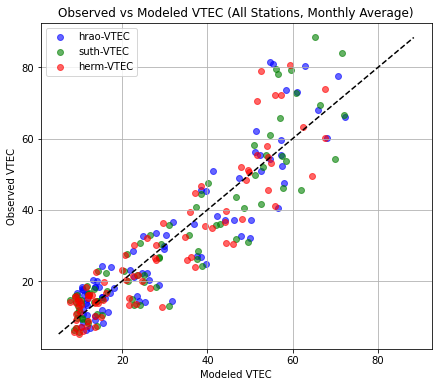

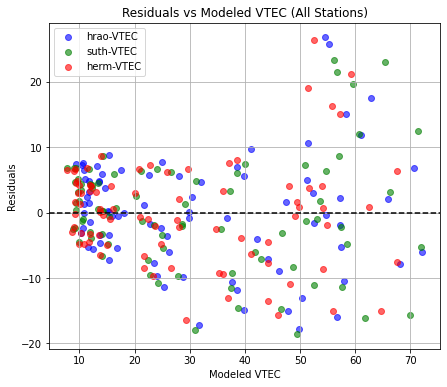

/home/user/miniconda3/envs/py39/lib/python3.9/site-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)
/home/user/miniconda3/envs/py39/lib/python3.9/site-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)
/home/user/miniconda3/envs/py39/lib/python3.9/site-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


<Figure size 504x432 with 0 Axes>

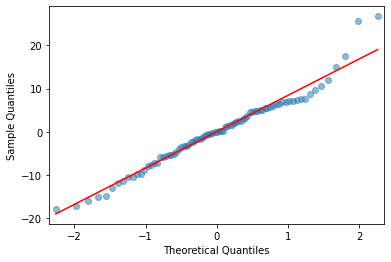

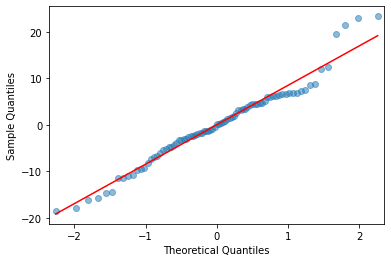

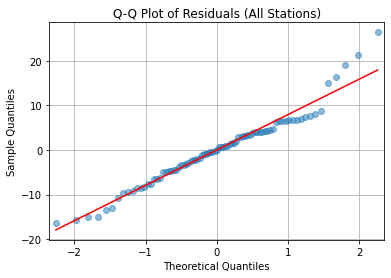

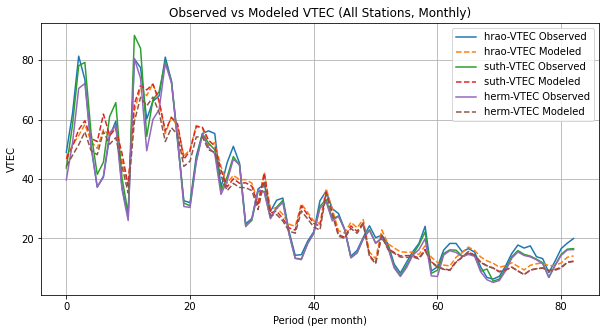

In [34]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
import pandas as pd

stations = ['hrao-VTEC', 'suth-VTEC', 'herm-VTEC']
colors = ['blue', 'green', 'red']  # color per station

# -----------------------------
# 1. Observed vs Predicted (All stations)
# -----------------------------
plt.figure(figsize=(7,6))
for station, color in zip(stations, colors):
    model = models[station]
    y = monthly_data[station]
    predicted = model.predict(X)
    
    plt.scatter(predicted, y, alpha=0.6, label=station, color=color)

# 1:1 reference line
min_val = min(monthly_data[stations].min())
max_val = max(monthly_data[stations].max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--')
plt.xlabel("Modeled VTEC")
plt.ylabel("Observed VTEC")
plt.title("Observed vs Modeled VTEC (All Stations, Monthly Average)")
plt.legend()
plt.grid()
plt.savefig('VTEC_Analysis_Plot_ObsvsModel.jpg')
plt.show()

# -----------------------------
# 2. Residuals vs Fitted (All stations)
# -----------------------------
plt.figure(figsize=(7,6))
for station, color in zip(stations, colors):
    model = models[station]
    residuals = model.resid
    predicted = model.predict(X)
    
    plt.scatter(predicted, residuals, alpha=0.6, label=station, color=color)

plt.axhline(0, color='k', linestyle='--')
plt.xlabel("Modeled VTEC")
plt.ylabel("Residuals")
plt.title("Residuals vs Modeled VTEC (All Stations)")
plt.legend()
plt.grid()
plt.show()

# -----------------------------
# 3. Q-Q Plot (All stations)
# -----------------------------
plt.figure(figsize=(7,6))
for station, color in zip(stations, colors):
    model = models[station]
    residuals = model.resid
    sm.ProbPlot(residuals).qqplot(line='s', alpha=0.5, color=color)

plt.title("Q-Q Plot of Residuals (All Stations)")
plt.grid()
plt.show()

# -----------------------------
# 4. Time Series Fit Plot (All stations)
# -----------------------------
plt.figure(figsize=(10,5))
for station, color in zip(stations, colors):
    model = models[station]
    y = monthly_data[station]
    predicted = model.predict(X)
    
    plt.plot(monthly_data.index, y, label=f"{station} Observed", linestyle='-')
    plt.plot(monthly_data.index, predicted, label=f"{station} Modeled", linestyle='--')

plt.xlabel("Period (per month)")
plt.ylabel("VTEC")
plt.title("Observed vs Modeled VTEC (All Stations, Monthly)")
plt.legend()
plt.grid()
plt.savefig('VTEC_Analysis_Plot_Model_Comparison.jpg')
plt.show()

# seasonally decomposed data

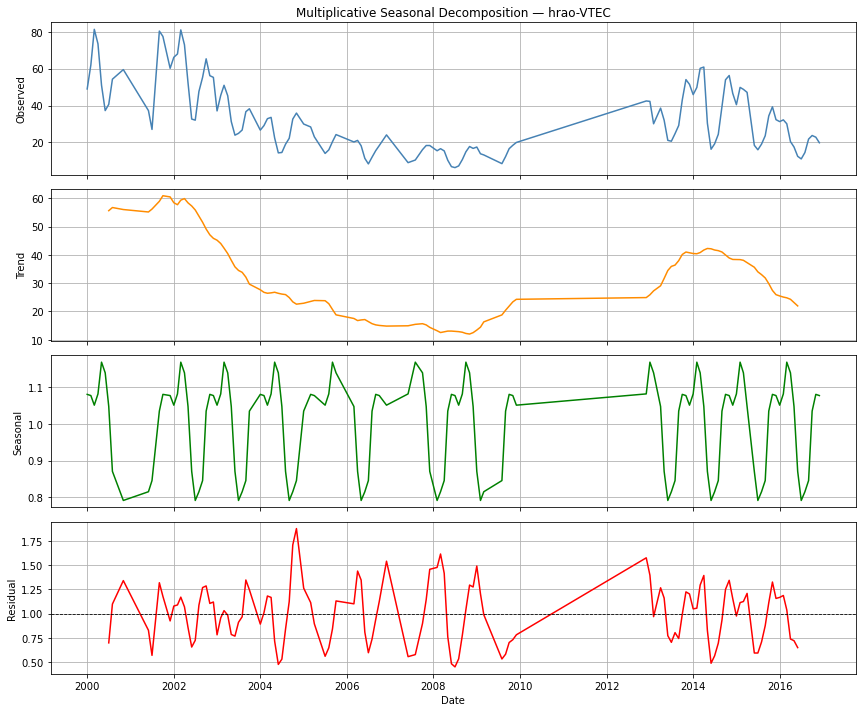

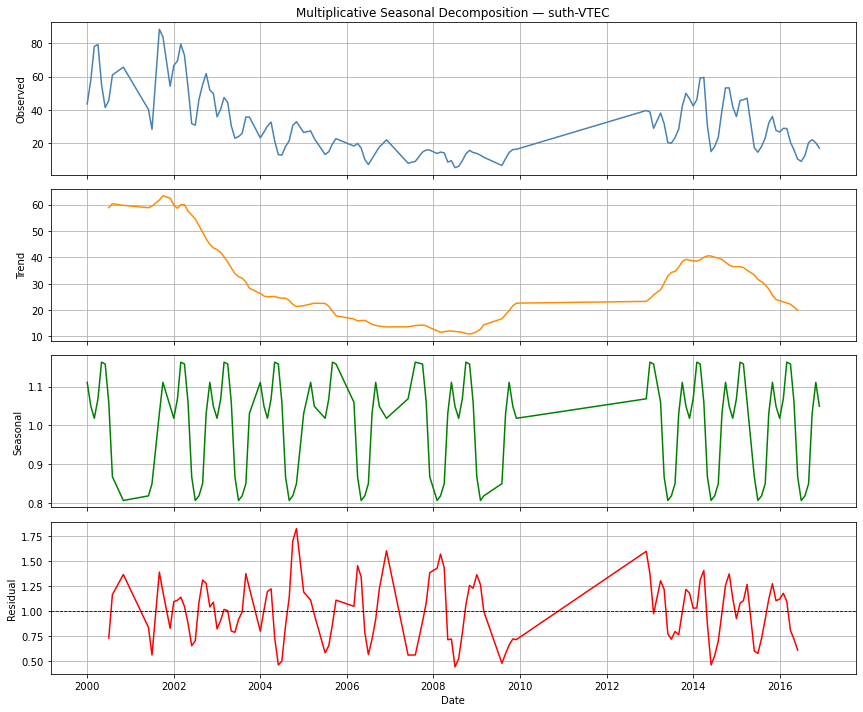

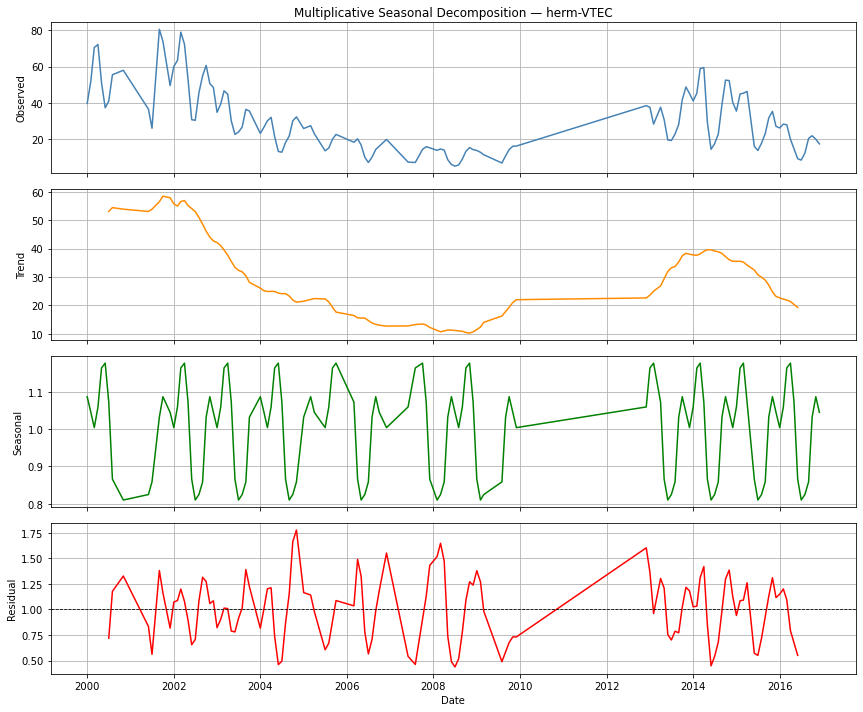

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

stations = ['hrao-VTEC', 'suth-VTEC', 'herm-VTEC']

# Ensure YearMonth is datetime and set as index
decomp_data = stations_monthly.copy()
#decomp_data['YearMonth'] = decomp_data['YearMonth'].dt.to_timestamp()
decomp_data = decomp_data.set_index('YearMonth')

# Store decomposition results for later use if needed
decomp_results = {}

for station in stations:

    series = decomp_data[station].copy()

    # Multiplicative decomposition requires strictly positive values
    # Cubic spline interpolation to fill any remaining NaNs
    series = series.interpolate(method='spline', order=3)

    # Period = 12 months (annual cycle)
    result = seasonal_decompose(series, model='multiplicative', period=12)

    decomp_results[station] = result

    # Plot
    fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

    axes[0].plot(series, color='steelblue')
    axes[0].set_ylabel('Observed')
    axes[0].set_title(f'Multiplicative Seasonal Decomposition — {station}')
    axes[0].grid(True)

    axes[1].plot(result.trend, color='darkorange')
    axes[1].set_ylabel('Trend')
    axes[1].grid(True)

    axes[2].plot(result.seasonal, color='green')
    axes[2].set_ylabel('Seasonal')
    axes[2].grid(True)

    axes[3].plot(result.resid, color='red')
    axes[3].axhline(1, color='black', linestyle='--', linewidth=0.8)  # reference at 1 for multiplicative
    axes[3].set_ylabel('Residual')
    axes[3].set_xlabel('Date')
    axes[3].grid(True)

    plt.tight_layout()
    plt.savefig(f'seasonal_decomposition_{station}.jpg', dpi=150)
    plt.show()

In [36]:
decomp_data = decomp_data.reset_index()
decomp_data

,YearMonth,hrao-VTEC,suth-VTEC,herm-VTEC
0,2000-01-01,48.984570,43.678421,39.683801
1,2000-02-01,62.031318,58.217056,52.033924
2,2000-03-01,81.367264,78.160147,70.509034
3,2000-04-01,73.485655,79.246056,72.160000
4,2000-05-01,51.021451,55.409806,51.092551
...,...,...,...,...
129,2016-08-01,14.466417,12.773159,12.323604
130,2016-09-01,21.757465,20.502670,20.395894
131,2016-10-01,23.705247,22.271101,21.872049
132,2016-11-01,22.798002,20.444004,19.985979


In [37]:
monthly_data_decomp = drivers.merge(decomp_data, on='YearMonth')
print(monthly_data_decomp)

    YearMonth        f107     index        dst             ap  CO2_Level  \
0  2000-01-01  153.432258  0.162888 -18.616379    1573.208333     369.45   
1  2000-02-01  168.589310  0.163873 -18.712798       8.333333     369.71   
2  2000-03-01  206.673548  0.166160  -6.358790  967131.666667     370.75   
3  2000-04-01  185.490000  0.166270 -26.670118  975394.187500     371.98   
4  2000-05-01  188.385484  0.164477 -15.392603  633332.625000     371.74   
..        ...         ...       ...        ...            ...        ...   
78 2009-08-01   69.025806  0.150467  -2.333333      10.515000     386.29   
79 2009-09-01   71.193333  0.150827  -0.706065      10.476852     384.95   
80 2009-10-01   71.835484  0.151199  -0.593842       8.883621     384.64   
81 2009-11-01   72.016667  0.151580  -2.535660       7.718750     386.23   
82 2009-12-01   74.354839  0.151863   0.864329       4.919355     387.63   

    hrao-VTEC  suth-VTEC  herm-VTEC  
0   48.984570  43.678421  39.683801  
1   62.0313

In [38]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

# predictors
predictors = ['index', 'dst', 'CO2_Level', 'f107', 'ap']

# stations
stations = ['hrao-VTEC', 'suth-VTEC', 'herm-VTEC']

# scale predictors once
scaler = StandardScaler()
X_scaled = scaler.fit_transform(monthly_data_decomp[predictors])
X = pd.DataFrame(X_scaled, columns=predictors)

# add constant
X = sm.add_constant(X)

# VIF (same for all stations)
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("\nVIF Table")
print(vif_data)

# Regression for each station


models = {}

for station in stations:
    
    y = monthly_data_decomp[station].copy()
    
    model = sm.OLS(y, X).fit()
    
    models[station] = model
    
    print(model.summary())


VIF Table
     feature        VIF
0      const   1.000000
1      index  36.558371
2        dst   1.485466
3  CO2_Level   5.541552
4       f107  37.754215
5         ap   1.967897
                            OLS Regression Results                            
Dep. Variable:              hrao-VTEC   R-squared:                       0.830
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     75.25
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           3.30e-28
Time:                        12:24:42   Log-Likelihood:                -294.70
No. Observations:                  83   AIC:                             601.4
Df Residuals:                      77   BIC:                             615.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std er

### Seasonal Decomposition does no difference

In [39]:
# group by years
drivers['YearMonth'] = pd.to_datetime(drivers['YearMonth'], errors='coerce')
drivers = drivers.groupby(drivers['YearMonth'].dt.to_period('Y')).mean().reset_index()
#drivers['YearMonth'] = drivers['YearMonth'].dt.to_timestamp()
print(drivers)

   YearMonth        f107     index        dst             ap   CO2_Level
0       2000  180.031601  0.165271 -19.070624  621555.900988  369.706667
1       2001  181.011594  0.164827 -17.862724  569361.488726  371.319167
2       2002  180.848175  0.165974 -17.832669  441407.922069  373.700000
3       2003  129.187534  0.159335 -20.418742    1728.075992  375.456000
4       2004  106.248777  0.155876 -16.801426    1185.259666  377.746364
5       2005   91.870073  0.153700 -21.418471     341.436328  379.983333
6       2006   80.016374  0.152292  -7.713919      35.344392  382.090833
7       2007   73.074695  0.151133  -5.833229      12.178116  384.025000
8       2008   68.595644  0.150784  -7.941362      12.048497  385.831667
9       2009   70.535610  0.150843  -2.274881       9.271972  387.642500
10      2010   79.953584  0.152995  -7.632558      12.264617  390.101667
11      2011  112.970518  0.157220  -7.630085   33743.382872  391.850833
12      2012  124.780645  0.159666  -5.882698    22

In [40]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

# predictors
predictors = ['index', 'dst', 'CO2_Level', 'f107', 'ap']

# stations
stations = ['hrao-VTEC', 'suth-VTEC', 'herm-VTEC']

# scale predictors once
scaler = StandardScaler()
X_scaled = scaler.fit_transform(yearly_data[predictors])
X = pd.DataFrame(X_scaled, columns=predictors)

# add constant
X = sm.add_constant(X)

# VIF (same for all stations)
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("\nVIF Table")
print(vif_data)

# Regression for each station


models = {}

for station in stations:
    
    y = yearly_data[station].copy()
    
    model = sm.OLS(y, X).fit()
    
    models[station] = model
    
    print(model.summary())


VIF Table
     feature         VIF
0      const    1.000000
1      index  106.710306
2        dst    1.378006
3  CO2_Level    2.333610
4       f107  114.689799
5         ap    1.979466
                            OLS Regression Results                            
Dep. Variable:              hrao-VTEC   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.801
Method:                 Least Squares   F-statistic:                     8.266
Date:                Tue, 07 Apr 2026   Prob (F-statistic):             0.0311
Time:                        12:25:55   Log-Likelihood:                -30.304
No. Observations:                  10   AIC:                             72.61
Df Residuals:                       4   BIC:                             74.42
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef   

/home/user/miniconda3/envs/py39/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "
/home/user/miniconda3/envs/py39/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "
/home/user/miniconda3/envs/py39/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


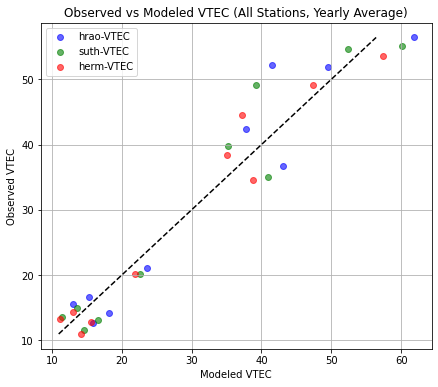

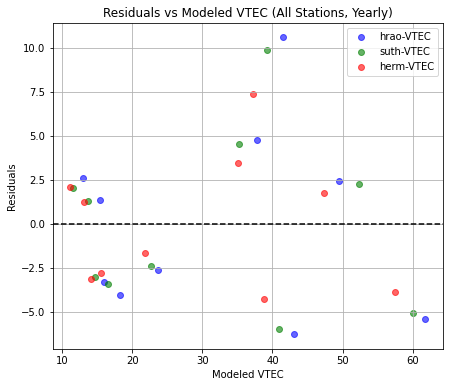

/home/user/miniconda3/envs/py39/lib/python3.9/site-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)
/home/user/miniconda3/envs/py39/lib/python3.9/site-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)
/home/user/miniconda3/envs/py39/lib/python3.9/site-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


<Figure size 504x432 with 0 Axes>

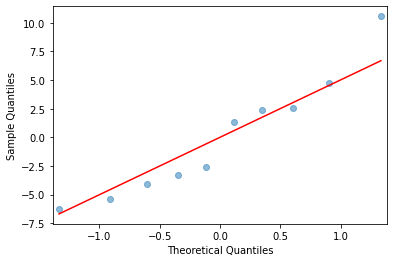

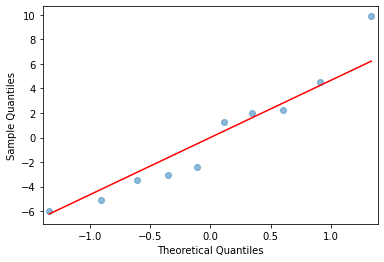

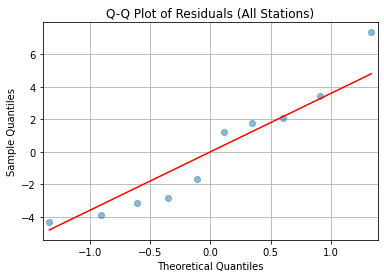

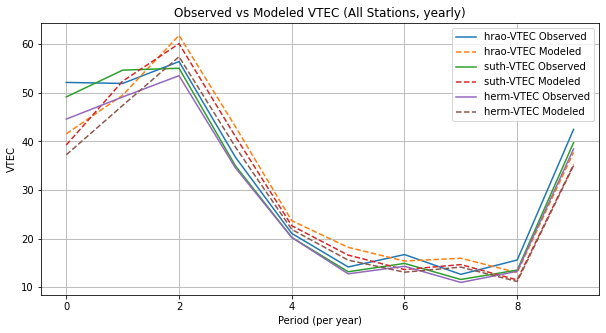

In [41]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
import pandas as pd

stations = ['hrao-VTEC', 'suth-VTEC', 'herm-VTEC']
colors = ['blue', 'green', 'red']  # color per station

# -----------------------------
# 1. Observed vs Predicted (All stations)
# -----------------------------
plt.figure(figsize=(7,6))
for station, color in zip(stations, colors):
    model = models[station]
    y = yearly_data[station]
    predicted = model.predict(X)
    
    plt.scatter(predicted, y, alpha=0.6, label=station, color=color)

# 1:1 reference line
min_val = min(yearly_data[stations].min())
max_val = max(yearly_data[stations].max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--')
plt.xlabel("Modeled VTEC")
plt.ylabel("Observed VTEC")
plt.title("Observed vs Modeled VTEC (All Stations, Yearly Average)")
plt.legend()
plt.grid()
plt.savefig('VTEC_Analysis_Plot_ObsvsModel(Yearly).jpg')
plt.show()

# -----------------------------
# 2. Residuals vs Fitted (All stations)
# -----------------------------
plt.figure(figsize=(7,6))
for station, color in zip(stations, colors):
    model = models[station]
    residuals = model.resid
    predicted = model.predict(X)
    
    plt.scatter(predicted, residuals, alpha=0.6, label=station, color=color)

plt.axhline(0, color='k', linestyle='--')
plt.xlabel("Modeled VTEC")
plt.ylabel("Residuals")
plt.title("Residuals vs Modeled VTEC (All Stations, Yearly)")
plt.legend()
plt.grid()
plt.show()

# -----------------------------
# 3. Q-Q Plot (All stations)
# -----------------------------
plt.figure(figsize=(7,6))
for station, color in zip(stations, colors):
    model = models[station]
    residuals = model.resid
    sm.ProbPlot(residuals).qqplot(line='s', alpha=0.5, color=color)

plt.title("Q-Q Plot of Residuals (All Stations)")
plt.grid()
plt.show()

# -----------------------------
# 4. Time Series Fit Plot (All stations)
# -----------------------------
plt.figure(figsize=(10,5))
for station, color in zip(stations, colors):
    model = models[station]
    y = yearly_data[station]
    predicted = model.predict(X)
    
    plt.plot(yearly_data.index, y, label=f"{station} Observed", linestyle='-')
    plt.plot(yearly_data.index, predicted, label=f"{station} Modeled", linestyle='--')

plt.xlabel("Period (per year)")
plt.ylabel("VTEC")
plt.title("Observed vs Modeled VTEC (All Stations, yearly)")
plt.legend()
plt.grid()
plt.savefig('VTEC_Analysis_Plot_Model_Comparison(Yearly).jpg')
plt.show()